# Whole analysis for TES till date. 

- Take data and plot parameters for number of transitions and transition time (use 1000 iterations data)
- Time spent in sync state using SEM
- Nodes which have high median time spent and high degree
- Finding connector hubs
- Finding betweenness centrality
- Finding control nodes
- All the regions get synchronised


In [28]:

%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns

from tes.DataUtils import DataUtils

### Creating object


In [29]:
analyse =AnalysisFunc()
reader = DataRead()
utils=DataUtils()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


### Plot of number of transitions and transition times


In [3]:
# load data 
data_folder = Path("../../data/results/processed/")
files=glob.glob(str(data_folder / "itr*.bz2"))

# Initialize a dictionary to store parameter lists
tranPer_params = {}  # to store number of transitions
trans_params = {}  # to store transition times
sync_params = {}  # to store time spent in sync states

for f in files:
    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]  # e.g., "bla"
    df_d = pd.read_pickle(f, compression="bz2")

    # Compute parameters
    params = analyse.compute_param(df_d, 0.05)

    # Store lists in the dictionary
    tranPer_params[f"{name_suffix}"] = params["tran_per"]
    trans_params[f"{name_suffix}"] = params["trans"]
    sync_params[f"{name_suffix}"] = params["sync"]




Number of transitions / 100 iteration [0, 37, 76, 110, 146, 178, 211, 255, 287, 324, 359]
Number of transition [6, 7, 12, 22, 23, 26, 27, 29, 30, 35, 37, 43, 44, 47, 48, 54, 57, 59, 62, 63, 64, 66, 67, 69, 73, 78, 79, 85, 92, 93, 98, 104, 106, 109, 110, 112, 115, 117, 121, 125, 130, 134, 135, 141, 142, 145, 148, 149, 151, 156, 158, 159, 162, 166, 168, 172, 173, 177, 180, 181, 182, 184, 187, 191, 192, 193, 197, 198, 210, 211, 214, 218, 223, 224, 226, 227, 228, 229, 232, 237, 239, 245, 246, 247, 250, 258, 262, 264, 274, 281, 283, 295, 296, 297, 298, 303, 305, 314, 320, 322, 326, 328, 329, 333, 334, 336, 342, 343, 345, 347, 348, 350, 351, 356, 359, 360, 365, 368, 370, 371, 375, 378, 382, 384, 385, 392, 395, 396, 397, 399, 402, 410, 412, 414, 416, 424, 425, 426, 430, 431, 439, 443, 451, 454, 455, 456, 460, 465, 470, 474, 476, 482, 484, 492, 498, 501, 502, 504, 505, 506, 508, 509, 511, 512, 514, 520, 531, 533, 536, 563, 566, 568, 574, 576, 582, 587, 588, 589, 593, 595, 597, 599, 601, 602, 6

In [4]:
node_order=np.array(["fn", "bla", "enti", "orbi", "peri", "pir", "re"])

non = np.r_[np.argsort([tranPer_params[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]

non




array([4, 1, 2, 5, 3, 6, 0])

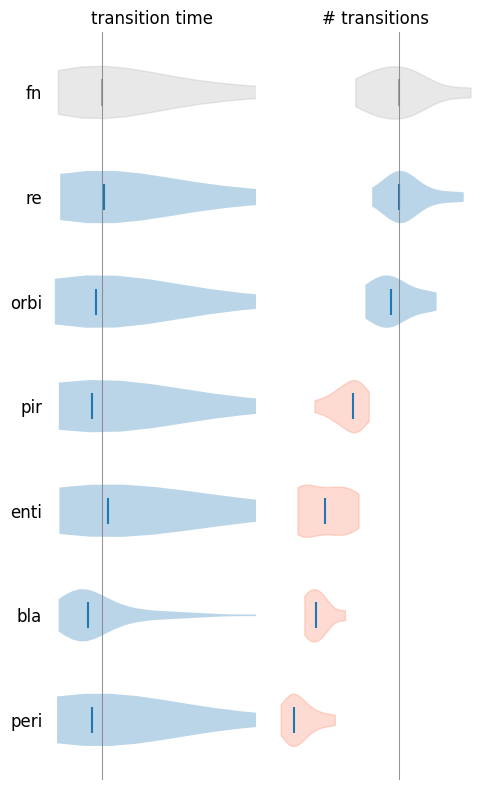

In [5]:
f,(ax1,ax2)= plt.subplots(1,2, figsize=(5,8), sharey=True)

_artists = ax1.violinplot(
    [trans_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 100)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("transition time")
ax1.axvline(np.median(trans_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)


_artists = ax2.violinplot(
    [np.diff(np.array(tranPer_params[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(tranPer_params["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)


f.subplots_adjust(wspace=0.8)
f.tight_layout()



## Time spent in sync state
 To check

In [ ]:
df=reader.data_read_bz2('results/processed/itr_peri.bz2')
plot_data=analyse.compute_time_spent(df,2000)



In [7]:
plot_data.keys()

dict_keys(['counts', 'time', 'time_spent'])

In [ ]:
data_folder = Path(f'../../data/results/processed')
print(data_folder)
# Use glob to match files with a pattern
#f=pd.read_csv('../../data/')

files = glob.glob(str(data_folder / "itr_*.bz2"))
print(files)

fig,ax = plt.subplots()

for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]
    
    df_itr = pd.read_pickle(f,compression='bz2')
    df=df_itr


    bs_values = [] # list to store values
    for i in range(0,500):
        df_rand=df.sample(n=200,axis='columns') 
        df_rand.columns=list(range(0,200))
        plot_data=analyse.compute_time_spent(df_rand,2000)
        time_arr=np.array(plot_data['time'])
        count_arr = np.array(plot_data['counts'])
        y=count_arr/count_arr[0]
        bs_values.append(y)

        # coverting bs_values to df

        bs_val_df=pd.DataFrame(bs_values).T

        mean = bs_val_df.mean(axis=1)
        sem = bs_val_df.sem(axis=1)

        l=analyse.compute_time_spent(df,2000)
        t=l['time']
        # fig,ax = plt.subplots()
    ax.plot(t,mean)
    ax.errorbar(t,mean,yerr=sem,fmt='none',ecolor='k',capsize=3)
    
plt.title('Considering time spent in sync state')
plt.xlabel('Time')
plt.ylabel('Number of Iterations')
plt.legend()

../../data/results/processed
['../../data/results/processed/itr_bla.bz2', '../../data/results/processed/itr_enti.bz2', '../../data/results/processed/itr_fn.bz2', '../../data/results/processed/itr_orbi.bz2', '../../data/results/processed/itr_peri.bz2', '../../data/results/processed/itr_pir.bz2', '../../data/results/processed/itr_re.bz2']
Number of transitions / 100 iteration [1, 44, 86]
Number of transition [0, 3, 4, 7, 13, 18, 19, 21, 22, 24, 26, 28, 31, 32, 41, 51, 52, 53, 54, 59, 60, 62, 64, 65, 68, 70, 71, 73, 75, 79, 80, 82, 85, 87, 89, 95, 98, 100, 102, 106, 110, 111, 118, 122, 125, 128, 129, 133, 136, 138, 139, 143, 147, 148, 153, 155, 156, 161, 164, 165, 166, 168, 170, 176, 177, 180, 182, 188, 189, 194, 197]
Number of transition with more than one transition or a fall back [18, 19, 24, 28, 32, 51, 53, 54, 68, 71, 73, 75, 79, 82, 110, 111, 128, 129, 136, 138, 139, 143, 155, 165, 166, 170, 194]
Number of transitions / 100 iteration [0, 37, 76, 110, 146, 178, 211, 255, 287, 324, 35

## Nodes which have high median time spent and high degree

In [11]:
df_nc=reader.data_read_bz2('raw/FN/nc_200.bz2')
df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')
# here G is the undirected graph
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)
df_r=df_nc.reset_index(drop=True)

In [12]:
i=0
f=5000
time_list=[]
node_list=[]
while f < df_r.shape[0]:
    l=analyse.compute_time_spent_mc(df_r.iloc[i:f,:])
    node_list.append(l)
    i=f
    f+=5000

df_time_spent = pd.DataFrame(node_list)
df_time_spent.shape

(127, 426)

In [13]:
# calculate median of every column
MTS = df_time_spent.median()
med_time_spent = list(MTS)
keys=list(range(0,426))
mts_dict=dict(zip(keys,med_time_spent))
mts_sorted =dict(sorted(mts_dict.items(), key=lambda item: item[1]))

In [14]:
degree = nx.degree_centrality(G)
degree_val =list(degree.values())

Text(0.5, 1.0, 'Scatter plot of Median Time Spent vs Degree')

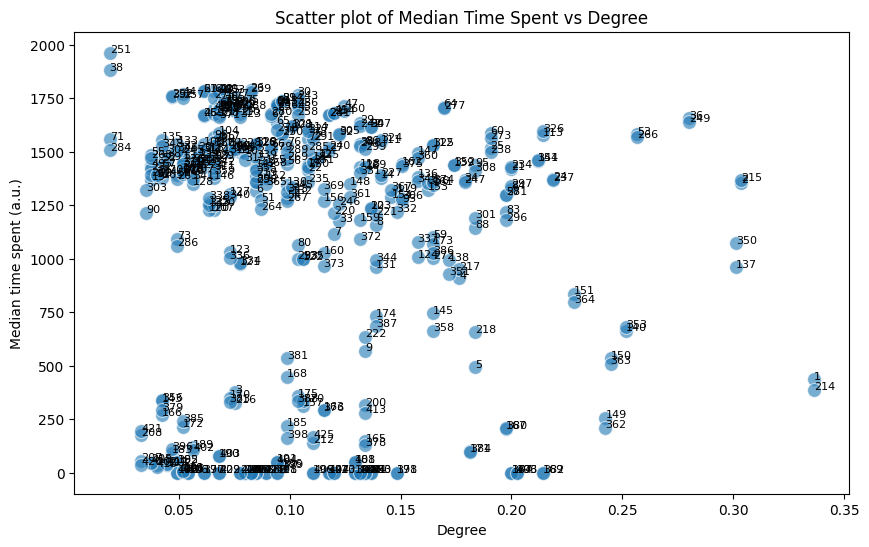

In [26]:
plt.figure(figsize=(10, 6))
ax=sns.scatterplot(x=degree_val, y=med_time_spent, s=100, alpha=0.6, edgecolor='w')

for i, txt in enumerate(keys):
    ax.annotate(txt, (degree_val[i], med_time_spent[i]), fontsize=8)


# defining function to plot nodes wrt their color

def node_color(color_nodes,color,degree,time_spent):
    plt.figure(figsize=(10, 6))
    ax=sns.scatterplot(x=degree_val, y=med_time_spent, s=100, alpha=0.6, edgecolor='w')
    
    for i, txt in enumerate(keys):
        ax.annotate(txt, (degree_val[i], med_time_spent[i]), fontsize=8)
    tdeg=[]
    tmts=[]
    for i in color_nodes:
        tdeg.append(degree_val[i])
        tmts.append(med_time_spent[i])
    
    ax=sns.scatterplot(x=tdeg,y=tmts,s=100,alpha=0.6,color='green')

    # Adjust the range as needed
    # plt.xlim(0, 0.15)  
    # plt.ylim(1200,1800)  
    
plt.xlabel('Degree')
plt.ylabel('Median time spent (a.u.)')
plt.title('Scatter plot of Median Time Spent vs Degree')

In [27]:
# To color the interesting nodes
# node_color(None,'k',degree_val,med_time_spent)

## Finding connector hubs 

- Nodes with high betweenness centrality, degree and nodal efficiency out of top 20 nodes

In [36]:
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)

bet_cent = nx.betweenness_centrality(G)
top_betweenness_centrality= dict(sorted(bet_cent.items(), key=lambda x: x[1], reverse=True))


degree_centrality = nx.degree_centrality(G)
top_degree_centrality = dict(sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True))

deg_cent_sorted =list(top_degree_centrality.keys())[0:20]
print(f'Top degree centrality nodes:{deg_cent_sorted}')

bet_cent_sorted = list(top_betweenness_centrality.keys())[0:20]
print(f'Top betweenness centrality nodes:{bet_cent_sorted}')

efficiency = {}
for node in G.nodes:
    # Calculate the sum of reciprocal of shortest path lengths from the node to all other nodes
    sp_lengths = nx.shortest_path_length(G, source=node)
    sum_reciprocal_sp = sum(1 / length for length in sp_lengths.values() if length > 0)
    
    # Calculate efficiency: E(v) = (1 / (N-1)) * sum(1 / d(v, u))
    # where N is the number of nodes and d(v, u) is the shortest path length between v and u
    efficiency[node] = sum_reciprocal_sp / (len(G.nodes) - 1)
    
efficiency_sorted = dict(sorted(efficiency.items(), key=lambda item: item[1],reverse=True))

top_nodal_efficiency = list(efficiency_sorted.keys())[0:20]
print(f'Top nodal efficiency nodes:{top_nodal_efficiency}')
common_node = list(set(deg_cent_sorted) & set(bet_cent_sorted) & set(top_nodal_efficiency))
common_node

Top degree centrality nodes:[1, 214, 2, 215, 137, 350, 36, 249, 53, 266, 140, 353, 150, 363, 149, 362, 151, 364, 24, 237]
Top betweenness centrality nodes:[214, 1, 137, 350, 2, 215, 36, 249, 266, 53, 95, 308, 171, 384, 164, 377, 167, 380, 326, 113]
Top nodal efficiency nodes:[1, 214, 137, 350, 2, 215, 36, 249, 140, 353, 150, 363, 149, 362, 151, 364, 53, 266, 141, 354]


[1, 2, 36, 137, 266, 53, 214, 215, 249, 350]

### Plotting connector hubs  

214,1  
215,2  
249,36  
137,350  
53,266  


In [42]:
data_folder = Path('../../data/raw/check_connector/')
files=glob.glob(str(data_folder / "itr_200*.bz2"))

print(files)
x=[]
itr_count=[]

# Initialize a dictionary to store parameter lists
transition_count = {}  # to store number of transitions
transition_time = {}  # to store transition times

for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]
    #x.append(name_suffix)
    df_d = pd.read_pickle(f, compression="bz2")

    # compute parameters
    params=analyse.compute_param(df_d,0.05)

    # store lists in dictionary
    transition_count[f"{name_suffix}"] = params["tran_per"]
    transition_time[f"{name_suffix}"] = params["trans"]
    # num=l['tran_per'][-1]
    # itr_count.append(num)

['../../data/raw/check_connector/itr_200_1.bz2', '../../data/raw/check_connector/itr_200_2.bz2', '../../data/raw/check_connector/itr_200_3.bz2', '../../data/raw/check_connector/itr_200_4.bz2', '../../data/raw/check_connector/itr_200_5.bz2', '../../data/raw/check_connector/itr_200_fn.bz2']
Number of transitions / 100 iteration [1, 46, 91]
Number of transition [0, 1, 2, 3, 4, 8, 13, 14, 16, 19, 21, 25, 28, 30, 35, 39, 40, 41, 42, 45, 50, 51, 53, 55, 56, 58, 59, 62, 63, 68, 69, 70, 73, 74, 75, 78, 82, 89, 92, 97, 98, 103, 105, 107, 108, 111, 117, 120, 121, 122, 129, 132, 134, 135, 136, 137, 138, 142, 144, 148, 150, 152, 156, 158, 162, 165, 166, 167, 168, 170, 171, 173, 174, 176, 179, 180, 183, 186, 187, 188, 190, 191, 198, 199]
Number of transition with more than one transition or a fall back [14, 16, 19, 28, 42, 63, 75, 92, 98, 107, 120, 122, 144, 156, 179, 187, 190, 199]
Number of transitions / 100 iteration [0, 38, 78]
Number of transition [1, 5, 6, 10, 13, 15, 20, 25, 27, 30, 31, 34, 

In [43]:
transition_count.keys()


dict_keys(['1', '2', '3', '4', '5', 'fn'])

In [51]:
node_order = np.array(['fn','1', '2', '3', '4', '5'])
non=np.r_[np.argsort([transition_count[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]
non

array([3, 5, 4, 2, 1, 0])

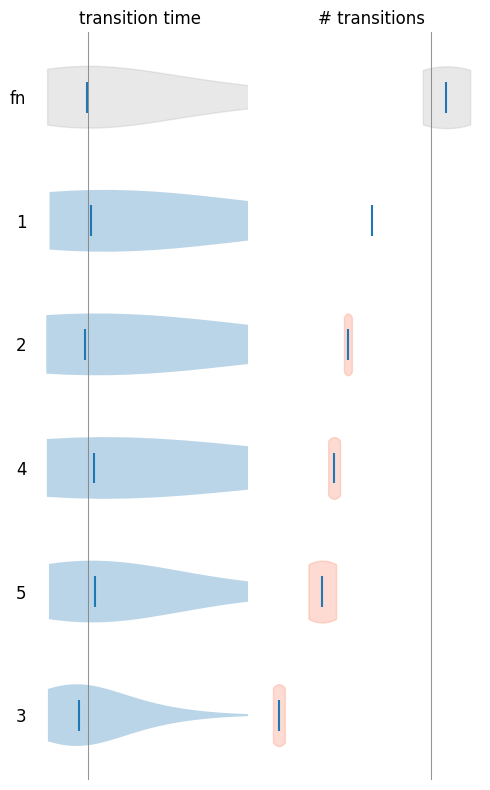

In [54]:
f,(ax1, ax2) = plt.subplots(1,2, figsize=(5,8),sharey = True)

_artists = ax1.violinplot(
    [transition_time[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 100)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("transition time")
ax1.axvline(np.median(trans_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

_artists = ax2.violinplot(
    [np.diff(np.array(transition_count[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(tranPer_params["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)


f.subplots_adjust(wspace=0.8)
f.tight_layout()

## Nodes in order of their betwenness centrality

In [57]:
# loading nodes in descending order of their betweenness centrality
b=reader.data_read_pkl('raw/betw.pkl')

# Getting node pairs after every 20th gap

nodes=list(b.keys())
betw_nodes=[nodes[0],nodes[1]]
plot_nodes =[]
i=1
while i < 426:
    if i%20==0:
        betw_nodes.append(nodes[i-2])
        betw_nodes.append(nodes[i-1])
    i+=1
print(betw_nodes)
print(len(betw_nodes))
betw_nodes
j=0
while j < len(betw_nodes):
    plot_nodes.append(betw_nodes[j])
    
    j+=2

print(plot_nodes)
    
print(len(plot_nodes))

#storing betweenness centrality values
val=[]
for i in plot_nodes:
    val.append(b[i])

[214, 1, 326, 113, 271, 58, 301, 88, 366, 153, 242, 29, 160, 373, 33, 246, 369, 156, 122, 335, 51, 264, 114, 327, 132, 345, 213, 0, 309, 96, 334, 121, 283, 70, 50, 263, 158, 371, 32, 245, 73, 286, 303, 90]
44
[214, 326, 271, 301, 366, 242, 160, 33, 369, 122, 51, 114, 132, 213, 309, 334, 283, 50, 158, 32, 73, 303]
22


n1 214,1
n2 326,113
n3 271,58
n4 301,88
n5 366,153
n6 242,29
n7 160,373
n8 33,246
n9 369, 156
n10 122, 335
n11 51,264
n12 114,327
n13 132, 345
n14 213, 0
n15 309,96
n16 334,121
n17 283,70
n18 50,263
n19 158,371
n20 32, 245
n21 73,286
n22 303,90

../../data/raw/random
['../../data/raw/random/itr_200_n20.bz2', '../../data/raw/random/itr_200_1.bz2', '../../data/raw/random/itr_200_2.bz2', '../../data/raw/random/itr_200_3.bz2', '../../data/raw/random/itr_200_4.bz2', '../../data/raw/random/itr_200_5.bz2', '../../data/raw/random/itr_200_6.bz2', '../../data/raw/random/itr_200_7.bz2', '../../data/raw/random/itr_200_8.bz2', '../../data/raw/random/itr_200_9.bz2', '../../data/raw/random/itr_200_n10.bz2', '../../data/raw/random/itr_200_n11.bz2', '../../data/raw/random/itr_200_n12.bz2', '../../data/raw/random/itr_200_n13.bz2', '../../data/raw/random/itr_200_n14.bz2', '../../data/raw/random/itr_200_n15.bz2', '../../data/raw/random/itr_200_n16.bz2', '../../data/raw/random/itr_200_n17.bz2', '../../data/raw/random/itr_200_n18.bz2', '../../data/raw/random/itr_200_n19.bz2', '../../data/raw/random/itr_200_n21.bz2']
Number of transitions / 100 iteration [0, 60, 120]
Number of transition [3, 4, 11, 14, 16, 17, 19, 20, 21, 23, 25, 26, 27, 34, 39, 40,

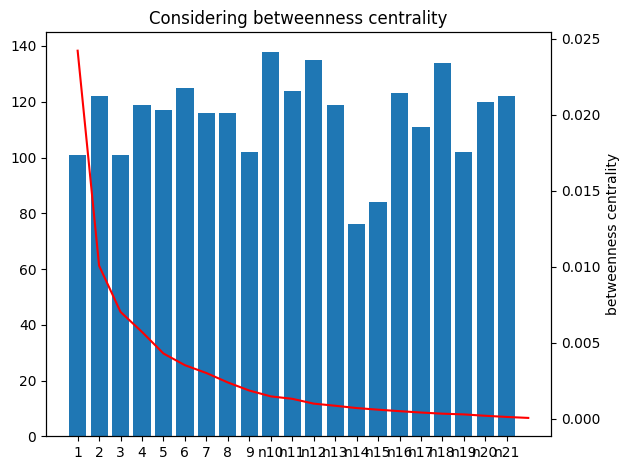

In [58]:
data_folder = Path(f'../../data/raw/random')
print(data_folder)
# Use glob to match files with a pattern
#f=pd.read_csv('../../data/')

files = glob.glob(str(data_folder / "itr_200*.bz2"))
print(files)
x=[]
itr_count=[]
for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]
    x.append(name_suffix)
    df_d = pd.read_pickle(f, compression="bz2")

    l=analyse.compute_param(df_d,0.05)
    num=l['tran_per'][-1]
    itr_count.append(num)

#plotting above as bar plot 
# sorting in ascending order

# uncomment below when need to plt in ascending order

# itr_count_arr=np.array(itr_count)
# ind=itr_count_arr.argsort()
# itr_count.sort()
# x=np.array(x)
# x=x[ind]

# SORT IN BETWEENNESS CENTRALITY DESCENDING ORDER

x_arr=np.array(x)
ind=x_arr.argsort()
x.sort()
itr_count=np.array(itr_count)
itr_count=itr_count[ind]

plt.bar(x,itr_count)
plt.twinx()


plt.plot(val,'r')
plt.title('Considering betweenness centrality')
plt.ylabel('betweenness centrality')
plt.xlabel('node set removed')
plt.tight_layout()
# print(f)

print(x)

#### Plotting betweenness centrality nodes on median time spent and degree plot

In [67]:
bet_cent_nodes = [214, 326, 271, 301, 366, 242, 160, 33, 369, 122, 51, 114, 132, 213, 309, 334, 283, 50, 158, 32, 73, 303]

In [ ]:
node_color(control_nodes,'k',degree_val,med_time_spent)

## Finding Control Nodes

In [65]:
control_nodes=[251,38,71,284,1,214,149,362]

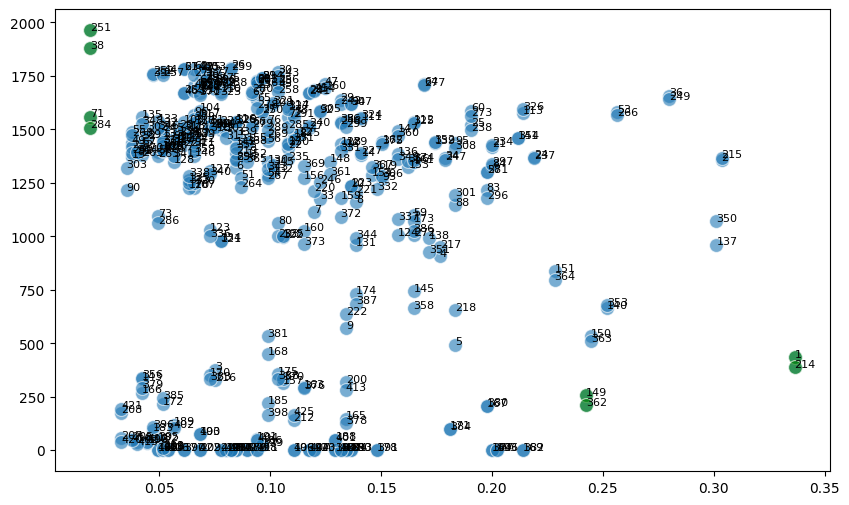

In [66]:
node_color(control_nodes,'k',degree_val,med_time_spent)

## All the regions get synchronised

In [69]:
df_nc_fn = reader.data_read_bz2('raw/FN/nc_200.bz2')
df_nc_peri = reader.data_read_bz2('raw/PERI/nc_200.bz2')

# resetting index for node community data  
df_r_fn = df_nc_fn.reset_index(drop=True)
df_r_peri = df_nc_peri.reset_index(drop=True)


In [73]:
# to find node count during formation of main cluster
i=0
f=5000
time_list=[]
node_count_list=[]
while f < df_r_peri.shape[0]:
    l=analyse.node_count(df_r_peri.iloc[i:f,:])
    time_list.append(l['timestep'])
    node_count_list.append(l['node_count'])
    i=f
    f+=5000

In [74]:
node_count_df_peri=pd.DataFrame(node_count_list).T
time_list_df_peri = pd.DataFrame(time_list).T

Text(0.5, 1.0, 'Main cluster formation during transition')

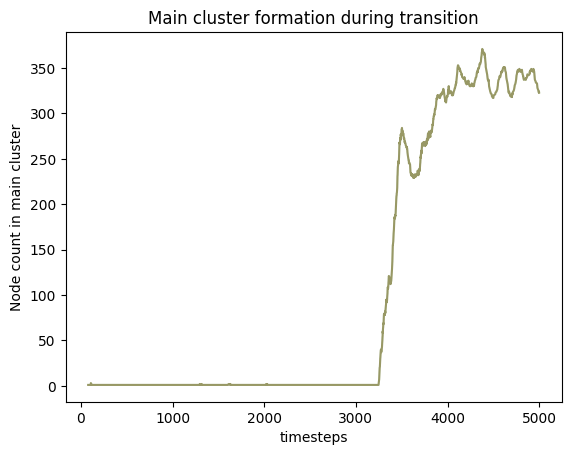

In [78]:

node_count_df_fn=pd.DataFrame(node_count_list).T
time_list_df_fn = pd.DataFrame(time_list).T

plt.plot(time_list_df_fn[1],node_count_df_fn[1],color='g',alpha = 0.5)
plt.plot(time_list_df_peri[1],node_count_df_peri[1],color='r',alpha = 0.2)
plt.xlabel('timesteps')
plt.ylabel('Node count in main cluster')
plt.title('Main cluster formation during transition')